In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Check device — MPS = Apple Silicon GPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Reload data
df = pd.read_csv('../data/processed/creditcard_features.csv')
feature_cols = [c for c in df.columns if c not in ['Class', 'Time', 'Amount']]
X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Training set: {X_train_bal.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"Input features: {X_train_bal.shape[1]}")

Using device: mps
Training set: 250,196 rows
Test set: 56,962 rows
Input features: 36


In [2]:
class FraudDetectionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_bal.values).to(device)
y_train_t = torch.FloatTensor(y_train_bal.values).to(device)
X_test_t  = torch.FloatTensor(X_test.values).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Initialize model
model     = FraudDetectionNet(input_dim=X_train_bal.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

FraudDetectionNet(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters: 51,585


Training Neural Network...
----------------------------------------
Epoch   5/30 | Loss: 0.0166
Epoch  10/30 | Loss: 0.0110
Epoch  15/30 | Loss: 0.0086
Epoch  20/30 | Loss: 0.0074
Epoch  25/30 | Loss: 0.0065
Epoch  30/30 | Loss: 0.0033
----------------------------------------
✅ Training complete


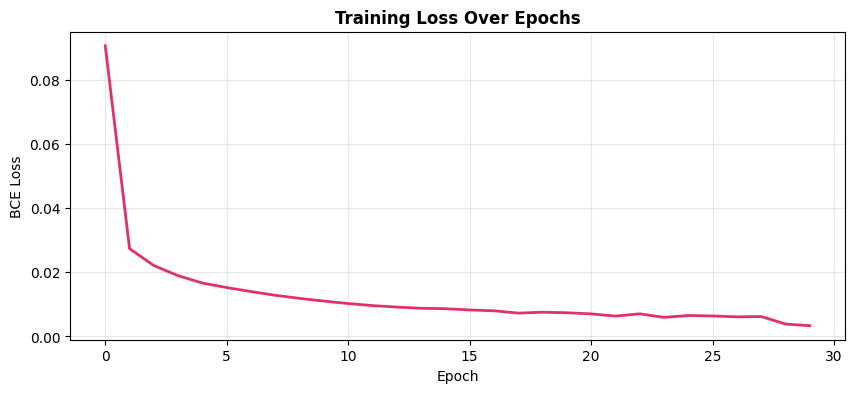

In [3]:
epochs = 30
train_losses = []

print("Training Neural Network...")
print("-" * 40)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch).squeeze()
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:>3}/{epochs} | Loss: {avg_loss:.4f}")

print("-" * 40)
print("✅ Training complete")

# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='#E1306C', linewidth=2)
plt.title('Training Loss Over Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid(alpha=0.3)
plt.savefig('../reports/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Evaluate neural network
model.eval()
with torch.no_grad():
    nn_proba = model(X_test_t).squeeze().cpu().numpy()

nn_pred = (nn_proba >= 0.5).astype(int)
nn_auc = roc_auc_score(y_test, nn_proba)
nn_ap = average_precision_score(y_test, nn_proba)

print("Neural Network Results:")
print(f"  ROC-AUC:           {nn_auc:.4f}")
print(f"  Avg Precision:     {nn_ap:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, nn_pred, target_names=['Legitimate', 'Fraud']))

# Final 3-way comparison
print("\n=== FINAL MODEL COMPARISON ===")
print(f"{'Metric':<20} {'Log. Reg':>12} {'XGBoost':>12} {'Neural Net':>12}")
print("-" * 58)

lr_auc = 0.9667
lr_ap = 0.7411
xgb_auc = 0.9755
xgb_ap = 0.8525

for metric, vals in [
    ('ROC-AUC',       [lr_auc, xgb_auc, nn_auc]),
    ('Avg Precision', [lr_ap,  xgb_ap,  nn_ap])
]:
    print(f"{metric:<20} {vals[0]:>12.4f} {vals[1]:>12.4f} {vals[2]:>12.4f}")

# Save model
torch.save(model.state_dict(), '../src/fraud_model.pth')
print("\n✅ Model saved to src/fraud_model.pth")

Neural Network Results:
  ROC-AUC:           0.9828
  Avg Precision:     0.8226

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.86      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962


=== FINAL MODEL COMPARISON ===
Metric                   Log. Reg      XGBoost   Neural Net
----------------------------------------------------------
ROC-AUC                    0.9667       0.9755       0.9828
Avg Precision              0.7411       0.8525       0.8226

✅ Model saved to src/fraud_model.pth


In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Retrain LR and XGBoost quickly to get probabilities back
df = pd.read_csv('../data/processed/creditcard_features.csv')
feature_cols = [c for c in df.columns if c not in ['Class', 'Time', 'Amount']]
X = df[feature_cols]
y = df['Class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)
lr_proba = lr.predict_proba(X_test)[:, 1]

xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                     scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                     random_state=42, verbosity=0)
xgb.fit(X_train_bal, y_train_bal)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

lr_ap = average_precision_score(y_test, lr_proba)
xgb_ap = average_precision_score(y_test, xgb_proba)

print("✅ Models retrained — ready for comparison")

✅ Models retrained — ready for comparison


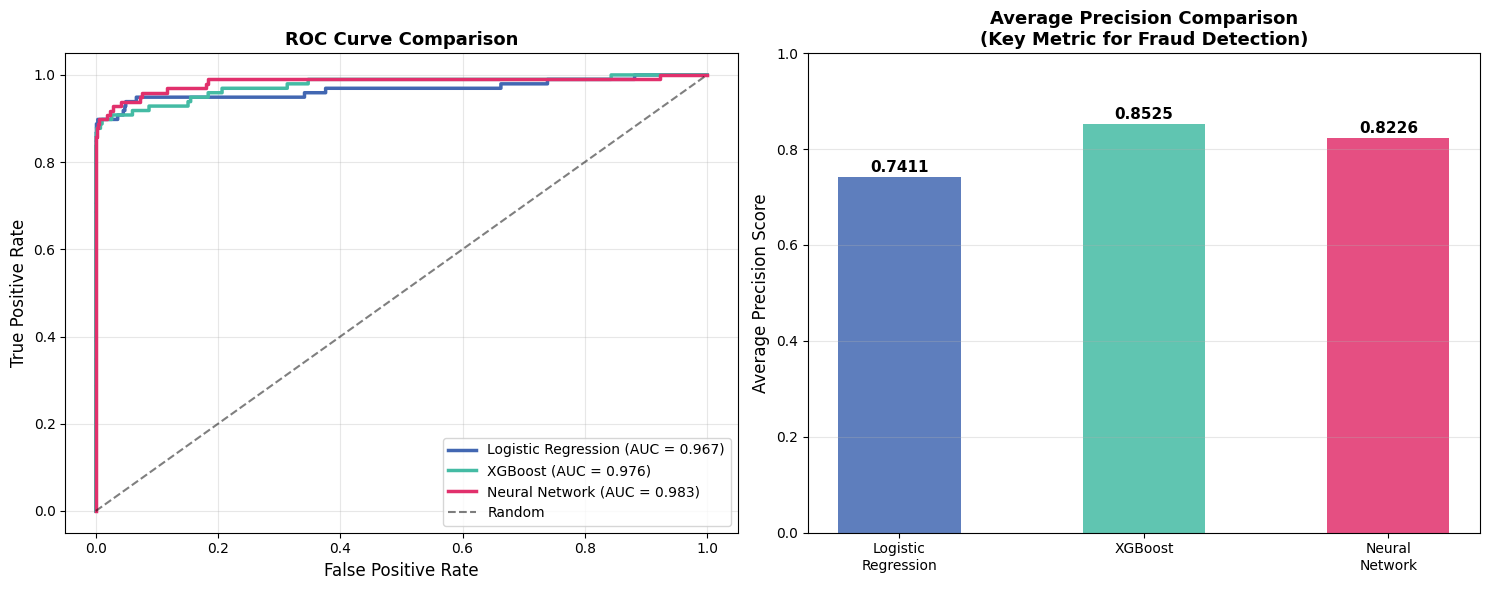

✅ Comparison chart saved


In [7]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curves
for name, proba, color in [
    ('Logistic Regression', lr_proba, '#4267B2'),
    ('XGBoost', xgb_proba, '#44BBA4'),
    ('Neural Network', nn_proba, '#E1306C')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC = {auc:.3f})')

axes[0].plot([0,1], [0,1], 'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Average Precision Bar Chart
models = ['Logistic\nRegression', 'XGBoost', 'Neural\nNetwork']
ap_scores = [lr_ap, xgb_ap, nn_ap]
colors = ['#4267B2', '#44BBA4', '#E1306C']

bars = axes[1].bar(models, ap_scores, color=colors, alpha=0.85, width=0.5)
axes[1].set_ylim([0, 1.0])
axes[1].set_ylabel('Average Precision Score', fontsize=12)
axes[1].set_title('Average Precision Comparison\n(Key Metric for Fraud Detection)',
                   fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar, score in zip(bars, ap_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved")